In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [3]:
data=pd.read_csv('../artifacts/IMDB Dataset.csv')

In [4]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Data Preprocessing

In [5]:
data.shape

(50000, 2)

In [6]:
data.duplicated().sum()

np.int64(418)

In [7]:
data.duplicated(subset='review').sum()

np.int64(418)

In [8]:
data[data.duplicated(subset='review', keep=False)].head(10)

,review,sentiment
42,"Of all the films I have seen, this one, The Ra...",negative
84,"We brought this film as a joke for a friend, a...",negative
140,"Before I begin, let me get something off my ch...",negative
219,Ed Wood rides again. The fact that this movie ...,negative
245,I have seen this film at least 100 times and I...,positive
480,From director Barbet Schroder (Reversal of For...,negative
513,"The story and the show were good, but it was r...",negative
636,I rented this thinking it would be pretty good...,negative
638,This movie has everything typical horror movie...,positive
701,I Enjoyed Watching This Well Acted Movie Very ...,positive


In [9]:
#remove duplicate
data = data.drop_duplicates(subset='review')

In [10]:
data = data.reset_index(drop=True)

In [11]:
data.duplicated(subset='review').sum()

np.int64(0)

In [12]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

## Text Preprocessing

In [13]:
import re
import string

#### convert uppercase to lowercase

In [14]:
data["review"]=data["review"].apply(lambda x:" ".join(x.lower() for x in x.split()))

In [15]:
data["review"].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production. <br /><br />the...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: review, dtype: str

#### Remove Links

In [16]:
data["review"]=data["review"].apply(lambda x: " ".join(re.sub(r'^https?:\/\/.*[\r\n]*','',x,flags=re.MULTILINE) for x in x.split()))

In [17]:
data["review"].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production. <br /><br />the...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: review, dtype: str

#### Remove Punctuations

In [18]:
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text=text.replace(punctuation,'')
    return text

data["review"]=data["review"].apply(remove_punctuations)

In [19]:
data["review"].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production br br the filmin...
2    i thought this was a wonderful way to spend ti...
3    basically theres a family where a little boy j...
4    petter matteis love in the time of money is a ...
Name: review, dtype: str

#### Remove numbers

In [20]:
data["review"]=data["review"].str.replace('\d+', '',regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Chirath Rasandun\AppData\Local\Temp\ipykernel_10228\782582486.py:1: SyntaxWarning: invalid escape sequence '\d'
  data["review"]=data["review"].str.replace('\d+', '',regex=True)


In [21]:
data["review"].tail()

49577    i thought this movie did a down right good job...
49578    bad plot bad dialogue bad acting idiotic direc...
49579    i am a catholic taught in parochial elementary...
49580    im going to have to disagree with the previous...
49581    no one expects the star trek movies to be high...
Name: review, dtype: str

#### Remove stopwords

In [22]:
!pip install nltk

In [23]:
import nltk

In [24]:
nltk.download('stopwords',download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
with open('../static/model/corpora/stopwords/english','r') as file:
    sw=file.read().splitlines()

In [26]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [27]:
data['review']=data['review'].apply(lambda x:" ".join(x for x in x.split() if x not in sw))

In [28]:
data["review"].head()

0    one reviewers mentioned watching oz episode yo...
1    wonderful little production br br filming tech...
2    thought wonderful way spend time hot summer we...
3    basically theres family little boy jake thinks...
4    petter matteis love time money visually stunni...
Name: review, dtype: str

#### Remove Stemming

In [29]:
from nltk.stem import PorterStemmer
ps=PorterStemmer()

In [30]:
data['review']=data['review'].apply(lambda x:" ".join(ps.stem(x) for x in x.split()))

In [31]:
data['review'].head()

0    one review mention watch oz episod youll hook ...
1    wonder littl product br br film techniqu unass...
2    thought wonder way spend time hot summer weeke...
3    basic there famili littl boy jake think there ...
4    petter mattei love time money visual stun film...
Name: review, dtype: str

#### Building Vocabulary

In [32]:
from collections import Counter
vocab=Counter()

In [33]:
vocab

Counter()

In [34]:
for sentence in data['review']:
    vocab.update(sentence.split())

In [35]:
len(vocab)

138642

In [36]:
data.shape

(49582, 2)

In [37]:
tokens=[key for key in vocab if vocab[key] >20]

In [38]:
tokens

['one',
 'review',
 'mention',
 'watch',
 'oz',
 'episod',
 'youll',
 'hook',
 'right',
 'exactli',
 'happen',
 'mebr',
 'br',
 'first',
 'thing',
 'struck',
 'brutal',
 'unflinch',
 'scene',
 'violenc',
 'set',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'heart',
 'timid',
 'pull',
 'punch',
 'regard',
 'drug',
 'sex',
 'hardcor',
 'classic',
 'use',
 'call',
 'nicknam',
 'given',
 'oswald',
 'maximum',
 'secur',
 'state',
 'focus',
 'mainli',
 'citi',
 'experiment',
 'section',
 'prison',
 'cell',
 'glass',
 'front',
 'face',
 'privaci',
 'high',
 'agenda',
 'em',
 'home',
 'muslim',
 'gangsta',
 'latino',
 'christian',
 'italian',
 'irish',
 'moreso',
 'death',
 'stare',
 'dodgi',
 'deal',
 'shadi',
 'agreement',
 'never',
 'far',
 'awaybr',
 'would',
 'say',
 'main',
 'appeal',
 'due',
 'fact',
 'goe',
 'wouldnt',
 'dare',
 'forget',
 'pretti',
 'pictur',
 'paint',
 'mainstream',
 'audienc',
 'charm',
 'doesnt',
 'mess',
 'around',
 'ever',
 'saw',
 'nasti',
 'surreal',
 'couldnt

In [39]:
len(tokens)

14378

In [40]:
def save_vocabulary(lines, filename):
    data='\n'.join(lines)
    file=open(filename,'w',encoding="utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens,'../static/model/vocabulary.txt')

#### Split data set

In [41]:
X=data['review']
y=data['sentiment']

In [42]:
!pip install scikit-learn

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [44]:
X_train.shape

(39665,)

In [45]:
X_test.shape

(9917,)

In [46]:
X_train

36053    movi far sophist intellig explor sexual tensio...
5179     attend camp chesapeak locat head chesapeak bay...
39999    movi littttl confus first usual like gina phil...
27983    read review movi gener pretti good thought see...
35027    sept mark small import mileston appreci horror...
                               ...                        
7881     rent mistak thought cursori examin box timetra...
33738    read documentari rent watch teenag children am...
20579    dont know guy talk first time watch movi two f...
20367    absolut love movi great realist look combat fo...
26199    ive seen variou hamlet ive taught play watch j...
Name: review, Length: 39665, dtype: str

#### TF-IDF Vectorization

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [48]:
tfidf_vectorizer = TfidfVectorizer(
    vocabulary=tokens,           # Use your pre-built vocabulary
    lowercase=False,              # Already lowercased
    norm='l2',                    # L2 normalization (default)
    use_idf=True,                 # Use inverse document frequency
    smooth_idf=True,               # Smooth idf weights
    sublinear_tf=False             # Do not use sublinear tf scaling (1+log(tf))
)

In [49]:
vectorized_x_train = tfidf_vectorizer.fit_transform(X_train).toarray()

In [50]:
vectorized_x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.0842347 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.07604949, 0.        , 0.09528898, ..., 0.        , 0.        ,
        0.        ],
       [0.03938098, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(39665, 14378))

In [51]:
vectorized_x_test = tfidf_vectorizer.transform(X_test).toarray()

In [52]:
print(f"Vectorized training shape: {vectorized_x_train.shape}")

Vectorized training shape: (39665, 14378)


In [53]:

print(f"Vectorized test shape: {vectorized_x_test.shape}")


Vectorized test shape: (9917, 14378)


In [54]:
#Check TF-IDF values for first sample
print(f"Sample TF-IDF vector (first 20 features):\n{vectorized_x_train[0][:20]}")

Sample TF-IDF vector (first 20 features):
[0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.0731456 0.       ]


In [55]:
y_train.value_counts()

sentiment
positive    19972
negative    19693
Name: count, dtype: int64

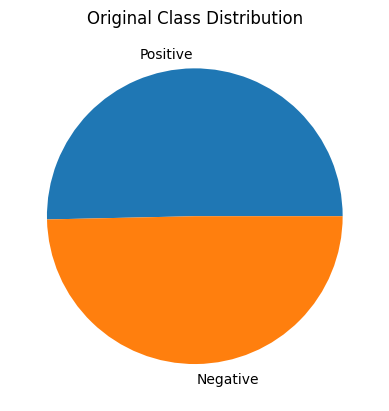

In [56]:
import matplotlib.pyplot as plt
plt.pie(np.array([y_train.value_counts()['positive'], y_train.value_counts()['negative']]), 
        labels=['Positive', 'Negative'])
plt.title('Original Class Distribution')
plt.show()

#### Model Training and Evaluation

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#### Logistic Regression

In [58]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

lr_model= LogisticRegression(random_state=42)
lr_model.fit(vectorized_x_train,y_train)
y_pred=lr_model.predict(vectorized_x_test)

print(classification_report(y_test,y_pred))
print('Confusion matrix:\n',confusion_matrix(y_test,y_pred))
print('Accuracy for test data:',accuracy_score(y_test,y_pred)*100)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5005
    positive       0.88      0.90      0.89      4912

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917

Confusion matrix:
 [[4391  614]
 [ 485 4427]]
Accuracy for test data: 88.91801956236766


from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define Logistic Regression model
lr_model = LogisticRegression()

# Hyperparameter distribution (same as your grid)
param_dist = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear'],
    'max_iter': [100]
}

# Randomized Search
random_search = RandomizedSearchCV(
    lr_model,
    param_distributions=param_dist,
    n_iter=3,         # Number of parameter settings to sample
    cv=3,
    scoring='accuracy',
    n_jobs=1,         # Avoid memory issues with multiple cores
    verbose=1,
    random_state=42
)

# Train
random_search.fit(vectorized_x_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_lr = random_search.best_estimator_

# Predictions
y_pred = best_lr.predict(vectorized_x_test)

# Evaluation
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy for test data:", accuracy_score(y_test, y_pred) * 100)

In [59]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    'C':[0.1,1,10],
    'solver':['liblinear'],
    'max_iter':[100]
}

# Grid Search
grid = GridSearchCV(
    lr_model,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)

# Train
grid.fit(vectorized_x_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_lr = grid.best_estimator_

# Predictions
y_pred = best_lr.predict(vectorized_x_test)

print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy for test data:", accuracy_score(y_test, y_pred) * 100)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5005
    positive       0.88      0.90      0.89      4912

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917

Confusion matrix:
 [[4394  611]
 [ 482 4430]]
Accuracy for test data: 88.978521730362


#### Naive Bayes

mnb = MultinomialNB()
mnb.fit(vectorized_x_train, y_train)
y_pred=mnb.predict(vectorized_x_test)

print(classification_report(y_test,y_pred))
print('Confusion matrix:\n',confusion_matrix(y_test,y_pred))
print('Accuracy for test data:',accuracy_score(y_test,y_pred)*100)

#### Decision Tree

dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train, y_train)

y_pred=dt.predict(vectorized_x_test)

print(classification_report(y_test,y_pred))
print('Confusion matrix:\n',confusion_matrix(y_test,y_pred))
print('Accuracy for test data:',accuracy_score(y_test,y_pred)*100)

#### RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(vectorized_x_train, y_train)
y_pred=rf.predict(vectorized_x_test)

print(classification_report(y_test,y_pred))
print('Confusion matrix:\n',confusion_matrix(y_test,y_pred))
print('Accuracy for test data:',accuracy_score(y_test,y_pred)*100)

In [60]:
import pickle

with open('../static/model/model.pickle','wb') as file:
    pickle.dump(best_lr,file)